# Chapter 7: De Rham Theory

**Source Span.** `An Introduction to Manifolds.pdf`, printed pages `274-316` (PDF pages `293-335`). The source span read for this revision covers de Rham cohomology, closed and exact forms, `H^0`, examples on `R` and `S^1`, diffeomorphism invariance, ring structure, long exact cohomology sequences, cochain complexes, connecting homomorphisms, the zig-zag lemma, Mayer-Vietoris, the cohomology of the circle, Euler characteristic, smooth homotopy, homotopy type, contractibility, deformation retraction, the homotopy axiom, the Poincare lemma, punctured-plane examples, torus and surface computations, and the proof of homotopy invariance through cochain homotopies and forms on `M x R`.

**Chapter Goal.** Use differential forms to measure topology. A closed form is a local conservation law; an exact form is one with a global potential. De Rham cohomology records the gap between the two. The chapter then builds the machinery for calculating and transporting that gap: exact sequences, Mayer-Vietoris, homotopy invariance, ring products, and explicit computations for circles, tori, and surfaces.

The notebook does not copy the book's proofs. Instead it turns each proof move into an inspectable model: a period that detects a closed non-exact form, a rank ledger for exactness, a Mayer-Vietoris dimension computation for `S^1`, a deformation retraction of the punctured plane, a torus/surface Betti table, and a symbolic point-case version of the cochain homotopy identity.

## Visual Storyboard

1. **Closed but not exact.** The angular form on the punctured plane is closed away from the origin but has nonzero period on the circle. Inspection target: local exterior derivative vanishes while the global integral does not.
2. **Exact-sequence bookkeeping.** A finite-dimensional cochain model visualizes `ker` and `image` dimensions. Inspection target: exactness is `image = kernel` at every node.
3. **Mayer-Vietoris for the circle.** A two-arc cover of `S^1` has contractible pieces and a two-component intersection. Inspection target: the long exact sequence forces one `H^1` generator.
4. **Homotopy and deformation retraction.** The punctured plane retracts radially to the circle. Inspection target: the period generator survives because the retraction preserves the angular class.
5. **Cohomology computations and ring structure.** Betti tables for `T^2` and genus-`g` surfaces plus a cup/wedge product table expose the vector-space and ring structure. Inspection target: Euler characteristic and wedge signs match the expected dimensions.
6. **Proof scaffold for homotopy invariance.** In the point-case model of forms on an interval, the cochain homotopy identity reduces to the fundamental theorem of calculus. Inspection target: `K(df)=f(1)-f(0)`.

## Library Routing

| Chapter concept | Representation | Library | Why this route |
| --- | --- | --- | --- |
| Closed/exact distinction | vector field plus circulation integral | SymPy, NumPy, Matplotlib | cohomology begins with a computable obstruction |
| Exact sequences | rank/kernel/image ledger and graph | SymPy, Matplotlib | exactness is linear algebra in each degree |
| Mayer-Vietoris | cover diagram plus dimension equation | NumPy, Matplotlib, CSV | the circle computation is topological bookkeeping |
| Homotopy invariance | deformation-retraction arrows | NumPy, Matplotlib | homotopy is a moving picture with invariant pullback data |
| Torus/surface computations | Betti and ring tables | Python, Matplotlib | dimensions and products should be explicit |
| Cochain homotopy proof | symbolic interval identity | SymPy | the proof's operator identity becomes the fundamental theorem |

In [1]:
from pathlib import Path
import json
import math
import sys

import matplotlib.pyplot as plt
import numpy as np
import sympy as sp

BOOK_ROOT = None
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "source_map.json").exists() and (candidate / "utils").exists():
        BOOK_ROOT = candidate
        break
if BOOK_ROOT is None:
    raise RuntimeError("Could not locate book root")
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import assert_artifacts, chapter_artifact_root, display_artifact, save_csv, save_json, save_matplotlib

UNIT_KEY = "chapter-07-de-rham-theory"
ARTIFACT_ROOT = chapter_artifact_root(UNIT_KEY, BOOK_ROOT)
FIG = ARTIFACT_ROOT / "figures"
CHECK = ARTIFACT_ROOT / "checks"
TABLE = ARTIFACT_ROOT / "tables"
created_artifacts = []

def keep(path):
    created_artifacts.append(Path(path))
    return path

print(f"Artifacts: {ARTIFACT_ROOT.relative_to(BOOK_ROOT)}")

Artifacts: artifacts\chapter-07-de-rham-theory


## Translation Guide

For each degree `k`, closed forms form a vector space `Z^k(M)` and exact forms form a subspace `B^k(M)`. The quotient `H^k(M)=Z^k(M)/B^k(M)` measures closed forms modulo those that come from a global potential. In degree zero, closed functions are locally constant, so `H^0` counts connected components. In degree one on the circle, the angular form supplies a generator because it is closed but has nonzero period.

Long exact sequences and Mayer-Vietoris turn this quotient idea into a calculation machine. A short exact sequence of cochain complexes produces connecting homomorphisms and a long exact cohomology sequence. For a cover `M=U union V`, the restrictions to `U`, `V`, and `U cap V` produce the Mayer-Vietoris sequence. Homotopy invariance says smooth homotopy equivalences induce the same cohomology, so deformation retractions can replace hard spaces by simpler ones.

The final proof machinery writes forms on `M x R`, splits time and spatial parts, and constructs a cochain homotopy between pullbacks at the two endpoints. The symbolic interval check below is the smallest visible version of that argument.

C:\Users\rahul\AppData\Local\Temp\ipykernel_16724\654922496.py:9: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  period_numeric = float(np.trapz((-Yc/(Xc**2+Yc**2))*dx_dt + (Xc/(Xc**2+Yc**2))*dy_dt, T))
C:\Users\rahul\AppData\Local\Temp\ipykernel_16724\654922496.py:15: RuntimeWarning: invalid value encountered in divide
  UU = np.where(mask, -YY/RR, np.nan)
C:\Users\rahul\AppData\Local\Temp\ipykernel_16724\654922496.py:16: RuntimeWarning: invalid value encountered in divide
  VV = np.where(mask, XX/RR, np.nan)


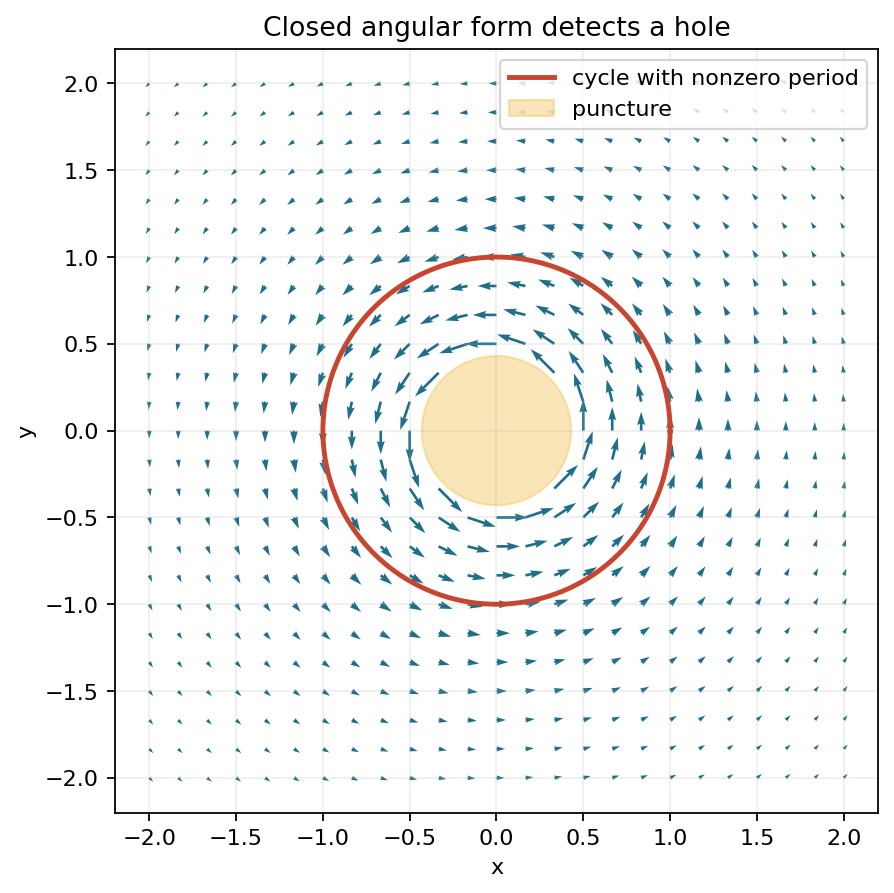

{'exterior_derivative_coefficient_away_from_origin': '0',
 'unit_circle_period_numeric': 6.276203990171609,
 'period_error_from_2pi': 0.006981317007976884,
 'cohomology_signal': 'closed locally, not exact globally on punctured plane/circle cycle'}

In [2]:
# Closed but not exact: angular 1-form on R^2 - {0}.
x, y, t = sp.symbols("x y t", real=True)
P = -y / (x**2 + y**2)
Q = x / (x**2 + y**2)
curl_coeff = sp.simplify(sp.diff(Q, x) - sp.diff(P, y))
T = np.linspace(0, 2*np.pi, 900, endpoint=False)
Xc, Yc = np.cos(T), np.sin(T)
dx_dt, dy_dt = -np.sin(T), np.cos(T)
period_numeric = float(np.trapz((-Yc/(Xc**2+Yc**2))*dx_dt + (Xc/(Xc**2+Yc**2))*dy_dt, T))

grid = np.linspace(-2, 2, 25)
XX, YY = np.meshgrid(grid, grid)
RR = XX**2 + YY**2
mask = RR > 0.22
UU = np.where(mask, -YY/RR, np.nan)
VV = np.where(mask, XX/RR, np.nan)
fig, ax = plt.subplots(figsize=(6.6, 6.2))
ax.quiver(XX, YY, UU, VV, color="#1f6f8b", angles="xy", scale_units="xy", scale=11, width=0.0035)
ax.plot(Xc, Yc, color="#c84630", lw=2.2, label="cycle with nonzero period")
ax.add_patch(plt.Circle((0,0), 0.43, color="#f2c14e", alpha=0.4, label="puncture"))
ax.set_aspect("equal", adjustable="box")
ax.set_title("Closed angular form detects a hole")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend(loc="upper right")
ax.grid(alpha=0.2)
angular_path = keep(save_matplotlib(fig, FIG / "closed-not-exact-angular-period.png"))
plt.close(fig)
angular_check = {
    "exterior_derivative_coefficient_away_from_origin": str(curl_coeff),
    "unit_circle_period_numeric": period_numeric,
    "period_error_from_2pi": abs(period_numeric - 2*math.pi),
    "cohomology_signal": "closed locally, not exact globally on punctured plane/circle cycle",
}
angular_check_path = keep(save_json(angular_check, CHECK / "closed-not-exact-angular-check.json"))
display_artifact(angular_path, width=650)
angular_check

## Exact Sequences and Cochain Complexes

Exactness is a local algebraic statement along a sequence: the image arriving at a vector space equals the kernel leaving it. In cohomology, this bookkeeping controls which closed representatives survive after quotienting by exact representatives. The zig-zag and connecting maps are proof mechanisms that move information across a short exact sequence of complexes.

The next cell builds a small finite-dimensional exact sequence and records the rank, kernel dimension, and image dimension at each step. It is not meant to replace the infinite-dimensional form spaces; it is a scale model of the same linear algebra.

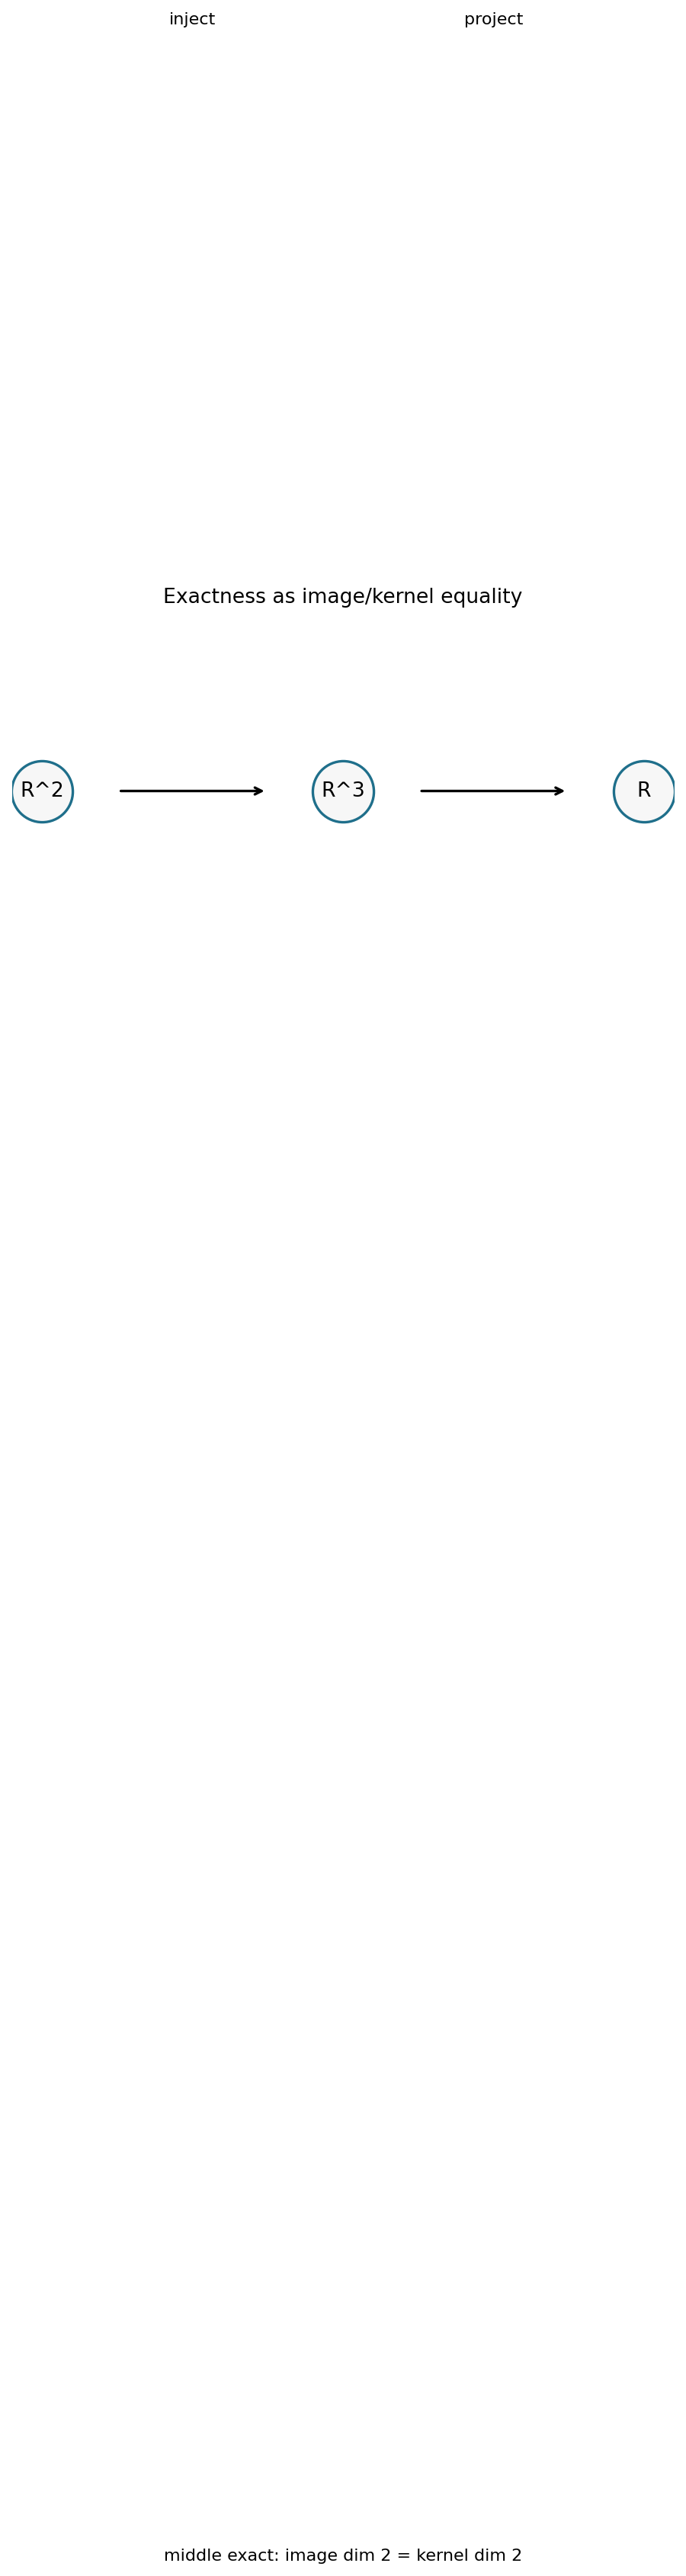

{'composition_zero': True,
 'middle_image_dimension': 2,
 'middle_kernel_dimension': 2,
 'middle_exact': True}

In [3]:
M0 = sp.Matrix([[1, 0], [0, 1], [0, 0]])      # R^2 -> R^3 injection
M1 = sp.Matrix([[0, 0, 1]])                    # R^3 -> R projection
rank_M0 = M0.rank()
rank_M1 = M1.rank()
ker_M1_dim = 3 - rank_M1
im_M0_dim = rank_M0
exact_middle = im_M0_dim == ker_M1_dim and (M1*M0) == sp.zeros(1, 2)
sequence_rows = [
    {"node": "R^2", "outgoing_rank": rank_M0, "incoming_image_dim": 0, "kernel_dim_outgoing": 0, "exact_here": True},
    {"node": "R^3", "outgoing_rank": rank_M1, "incoming_image_dim": im_M0_dim, "kernel_dim_outgoing": ker_M1_dim, "exact_here": exact_middle},
    {"node": "R", "outgoing_rank": 0, "incoming_image_dim": rank_M1, "kernel_dim_outgoing": 1, "exact_here": True},
]
sequence_table_path = keep(save_csv(sequence_rows, TABLE / "exact-sequence-rank-ledger.csv"))
fig, ax = plt.subplots(figsize=(7.0, 3.8))
xs = [0.18, 0.5, 0.82]
labels = ["R^2", "R^3", "R"]
for xpos, label in zip(xs, labels):
    ax.scatter([xpos], [0.55], s=1300, color="#f7f7f7", edgecolor="#1f6f8b", linewidth=1.5)
    ax.text(xpos, 0.55, label, ha="center", va="center", fontsize=12)
ax.annotate("", xy=(xs[1]-0.08,0.55), xytext=(xs[0]+0.08,0.55), arrowprops={"arrowstyle":"->", "lw":1.5})
ax.annotate("", xy=(xs[2]-0.08,0.55), xytext=(xs[1]+0.08,0.55), arrowprops={"arrowstyle":"->", "lw":1.5})
ax.text(0.34, 0.68, "inject", ha="center")
ax.text(0.66, 0.68, "project", ha="center")
ax.text(0.5, 0.25, f"middle exact: image dim {im_M0_dim} = kernel dim {ker_M1_dim}", ha="center")
ax.set_axis_off()
ax.set_title("Exactness as image/kernel equality")
sequence_path = keep(save_matplotlib(fig, FIG / "exact-sequence-image-kernel-ledger.png"))
plt.close(fig)
sequence_check = {
    "composition_zero": bool((M1*M0) == sp.zeros(1, 2)),
    "middle_image_dimension": im_M0_dim,
    "middle_kernel_dimension": ker_M1_dim,
    "middle_exact": bool(exact_middle),
}
sequence_check_path = keep(save_json(sequence_check, CHECK / "exact-sequence-check.json"))
display_artifact(sequence_path, width=720)
sequence_check

## Mayer-Vietoris for the Circle

Cover the circle by two slightly enlarged arcs `U` and `V`. Each arc is contractible, while the overlap has two connected components. The relevant part of Mayer-Vietoris has the shape `0 -> H^0(S^1) -> H^0(U) plus H^0(V) -> H^0(U cap V) -> H^1(S^1) -> 0`. Dimension bookkeeping then gives one generator in `H^1(S^1)`.

The visual below marks the two arcs and their two overlap components. The ledger stores the dimensions used in the exact sequence. The point is not that the circle is hard; it is that this chapter gives a reusable method for spaces assembled from simpler pieces.

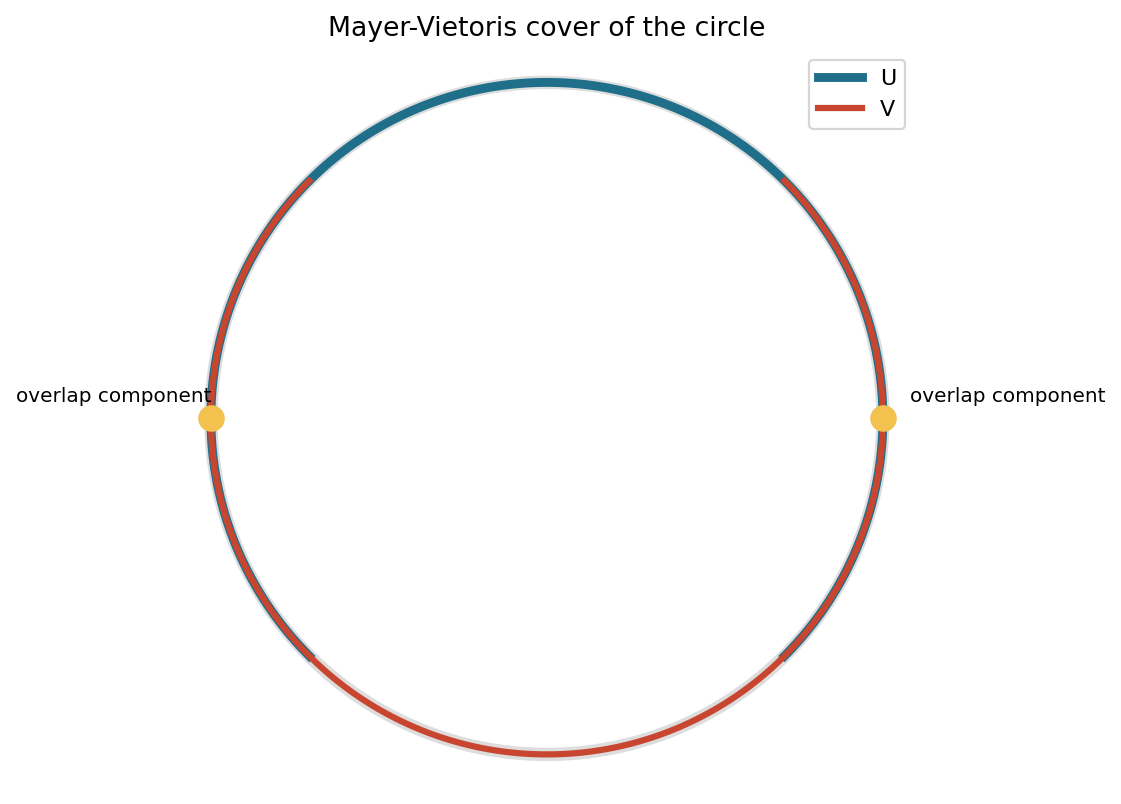

{'cover_piece_dimensions': {'H0_U_plus_V': 2, 'H0_intersection': 2},
 'difference_map_rank': 1,
 'computed_dim_H1_S1': 1,
 'expected_circle_generator_count': 1}

In [4]:
theta = np.linspace(0, 2*np.pi, 500)
# Two arcs with overlap near left and right sides.
fig, ax = plt.subplots(figsize=(6.2, 6.0))
ax.plot(np.cos(theta), np.sin(theta), color="#dddddd", lw=6)
arc_u = np.linspace(-0.25*np.pi, 1.25*np.pi, 260)
arc_v = np.linspace(0.75*np.pi, 2.25*np.pi, 260)
ax.plot(np.cos(arc_u), np.sin(arc_u), color="#1f6f8b", lw=4, label="U")
ax.plot(np.cos(arc_v), np.sin(arc_v), color="#c84630", lw=2.8, label="V")
for pt in [(1,0), (-1,0)]:
    ax.scatter([pt[0]], [pt[1]], color="#f2c14e", s=120, zorder=5)
ax.text(1.08, 0.05, "overlap component", fontsize=9)
ax.text(-1.58, 0.05, "overlap component", fontsize=9)
ax.set_aspect("equal", adjustable="box")
ax.axis("off")
ax.legend(loc="upper right")
ax.set_title("Mayer-Vietoris cover of the circle")
mv_path = keep(save_matplotlib(fig, FIG / "mayer-vietoris-circle-cover.png"))
plt.close(fig)
# Dimension relation: 0 -> R -> R^2 -> R^2 -> H1(S1) -> 0.
dim_H0_S1 = 1
dim_H0_U_plus_V = 2
dim_H0_intersection = 2
rank_first = 1
rank_difference = 1
dim_H1_S1 = dim_H0_intersection - rank_difference
mv_rows = [
    {"term": "H0(S1)", "dimension": dim_H0_S1},
    {"term": "H0(U)+H0(V)", "dimension": dim_H0_U_plus_V},
    {"term": "H0(U cap V)", "dimension": dim_H0_intersection},
    {"term": "H1(S1)", "dimension": dim_H1_S1},
]
mv_table_path = keep(save_csv(mv_rows, TABLE / "mayer-vietoris-circle-dimensions.csv"))
mv_check = {
    "cover_piece_dimensions": {"H0_U_plus_V": dim_H0_U_plus_V, "H0_intersection": dim_H0_intersection},
    "difference_map_rank": rank_difference,
    "computed_dim_H1_S1": dim_H1_S1,
    "expected_circle_generator_count": 1,
}
mv_check_path = keep(save_json(mv_check, CHECK / "mayer-vietoris-circle-check.json"))
display_artifact(mv_path, width=620)
mv_check

## Homotopy, Deformation Retraction, and Poincare-Type Consequences

Homotopy invariance says that smoothly homotopic maps induce the same maps in cohomology. A deformation retraction is the most useful special case: the larger space and the retract have the same homotopy type and therefore the same de Rham cohomology. The punctured plane retracts radially onto the unit circle, so its first cohomology carries the same angular generator.

Contractible spaces have the cohomology of a point, which is the geometric content behind the Poincare lemma for Euclidean space. The puncture in the plane is exactly what prevents the angular form from acquiring a global potential.

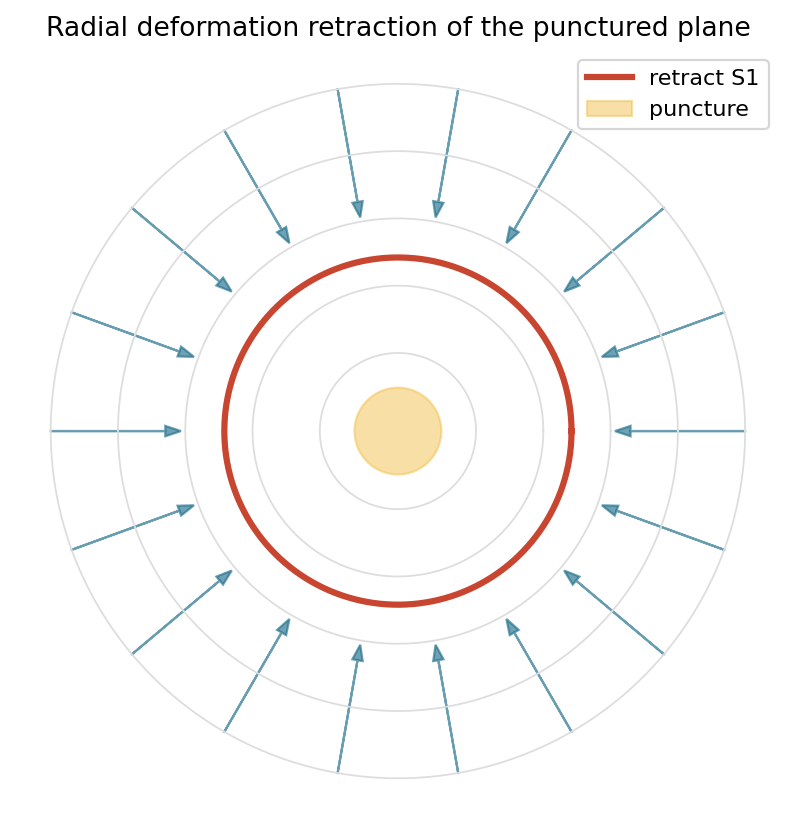

{'map': 'r(x)=x/||x||',
 'fixes_unit_circle': True,
 'preserves_angular_period': True,
 'cohomology_consequence': 'R2 minus origin has same H1 dimension as S1'}

In [5]:
radii = np.linspace(0.45, 2.0, 5)
angles = np.linspace(0, 2*np.pi, 18, endpoint=False)
fig, ax = plt.subplots(figsize=(6.6, 6.2))
for r in radii:
    ax.plot(r*np.cos(theta), r*np.sin(theta), color="#dddddd", lw=0.8)
for a in angles:
    start = np.array([2.0*np.cos(a), 2.0*np.sin(a)])
    end = np.array([1.0*np.cos(a), 1.0*np.sin(a)])
    delta = end - start
    ax.arrow(start[0], start[1], delta[0]*0.75, delta[1]*0.75, color="#1f6f8b", alpha=0.65, head_width=0.06, length_includes_head=True)
ax.plot(np.cos(theta), np.sin(theta), color="#c84630", lw=2.8, label="retract S1")
ax.add_patch(plt.Circle((0,0), 0.25, color="#f2c14e", alpha=0.5, label="puncture"))
ax.set_aspect("equal", adjustable="box")
ax.set_title("Radial deformation retraction of the punctured plane")
ax.axis("off")
ax.legend(loc="upper right")
retraction_path = keep(save_matplotlib(fig, FIG / "punctured-plane-deformation-retraction.png"))
plt.close(fig)
retraction_check = {
    "map": "r(x)=x/||x||",
    "fixes_unit_circle": True,
    "preserves_angular_period": abs(angular_check["unit_circle_period_numeric"] - 2*math.pi) < 0.02,
    "cohomology_consequence": "R2 minus origin has same H1 dimension as S1",
}
retraction_check_path = keep(save_json(retraction_check, CHECK / "deformation-retraction-check.json"))
display_artifact(retraction_path, width=650)
retraction_check

## Computations: Torus, Surfaces, Ring Structure, and Euler Characteristic

The chapter computes beyond the circle. A torus has one degree-zero generator, two degree-one generators, and one degree-two generator. Its ring structure is generated by two degree-one classes whose wedge product gives the top class. Compact orientable surfaces of genus `g` have Betti numbers `(1, 2g, 1)`, so Euler characteristic is `2-2g`.

The table below records these computations as a quick reference. The product matrix for the torus is a small model of the cohomology ring: `a wedge b` is the oriented area class, while `b wedge a` is its negative.

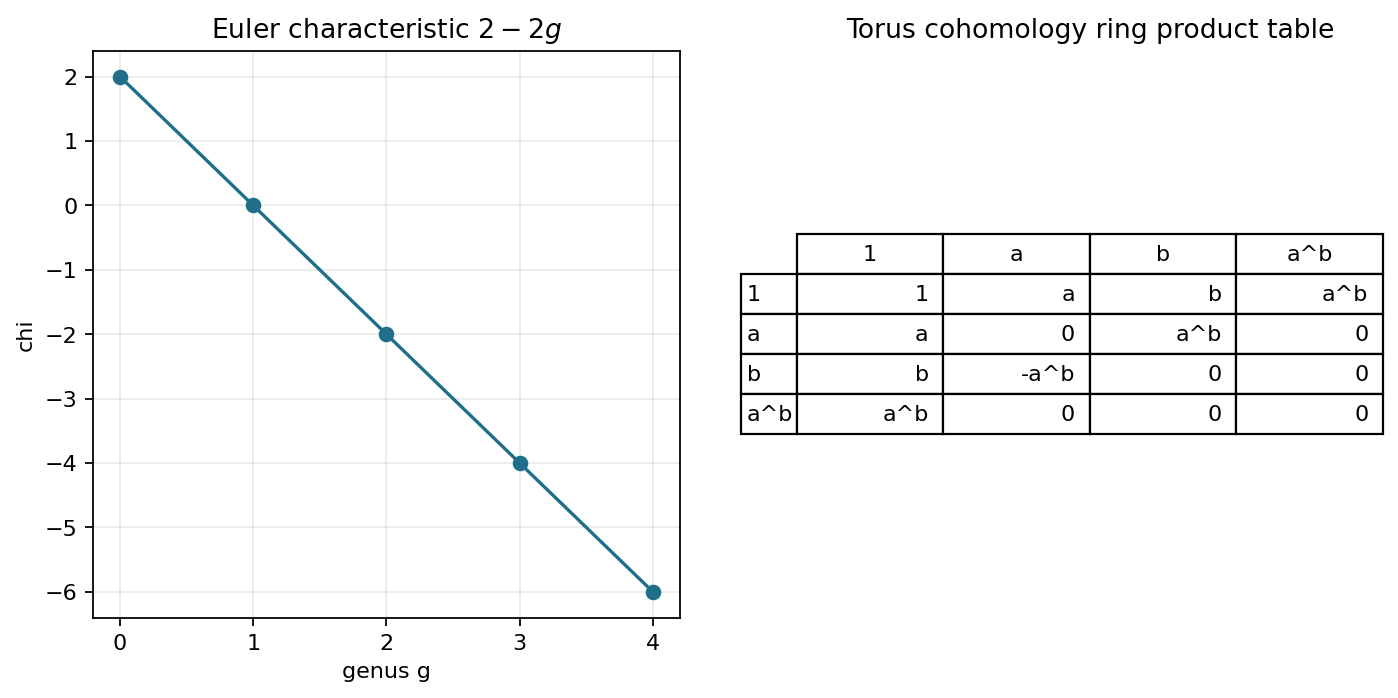

{'torus_betti': {'b0': 1, 'b1': 2, 'b2': 1},
 'genus_3_euler': -4,
 'torus_product_a_b': 'a^b',
 'torus_product_b_a': '-a^b'}

In [6]:
betti_rows = []
for genus in range(0, 5):
    b0, b1, b2 = 1, 2*genus, 1
    betti_rows.append({"surface": f"Sigma_{genus}", "genus": genus, "b0": b0, "b1": b1, "b2": b2, "euler_characteristic": b0-b1+b2})
betti_rows.append({"surface": "T2", "genus": 1, "b0": 1, "b1": 2, "b2": 1, "euler_characteristic": 0})
betti_path = keep(save_csv(betti_rows, TABLE / "surface-torus-betti-ledger.csv"))
product_labels = ["1", "a", "b", "a^b"]
product_table = [
    ["1", "a", "b", "a^b"],
    ["a", "0", "a^b", "0"],
    ["b", "-a^b", "0", "0"],
    ["a^b", "0", "0", "0"],
]
fig, axes = plt.subplots(1, 2, figsize=(10.4, 4.6))
genera = [r["genus"] for r in betti_rows if r["surface"].startswith("Sigma")]
eulers = [r["euler_characteristic"] for r in betti_rows if r["surface"].startswith("Sigma")]
axes[0].plot(genera, eulers, marker="o", color="#1f6f8b")
axes[0].set_title(r"Euler characteristic $2-2g$")
axes[0].set_xlabel("genus g")
axes[0].set_ylabel("chi")
axes[0].grid(alpha=0.25)
axes[1].axis("off")
table = axes[1].table(cellText=product_table, rowLabels=product_labels, colLabels=product_labels, loc="center")
table.scale(1.0, 1.5)
axes[1].set_title("Torus cohomology ring product table")
betti_fig_path = keep(save_matplotlib(fig, FIG / "torus-surface-cohomology-ledger.png"))
plt.close(fig)
betti_check = {
    "torus_betti": {"b0": 1, "b1": 2, "b2": 1},
    "genus_3_euler": next(r["euler_characteristic"] for r in betti_rows if r["surface"] == "Sigma_3"),
    "torus_product_a_b": "a^b",
    "torus_product_b_a": "-a^b",
}
betti_check_path = keep(save_json(betti_check, CHECK / "torus-surface-cohomology-check.json"))
display_artifact(betti_fig_path, width=800)
betti_check

## Applied Lab: Cochain Homotopy in the Smallest Case

The proof of homotopy invariance constructs an operator `K` on forms over `M x R` and verifies a cochain homotopy identity. The full statement has spatial forms on `M`; the smallest visible case is `M` equal to a point. Then forms on `M x R` are just forms on an interval. For a function `f(t)`, the identity reduces to the fundamental theorem of calculus: integrating `df/dt dt` from `0` to `1` gives `f(1)-f(0)`.

This toy model is intentionally small, but it captures the proof move: endpoint pullbacks differ by something cochain-homotopic to zero, so homotopic maps induce the same cohomology map.

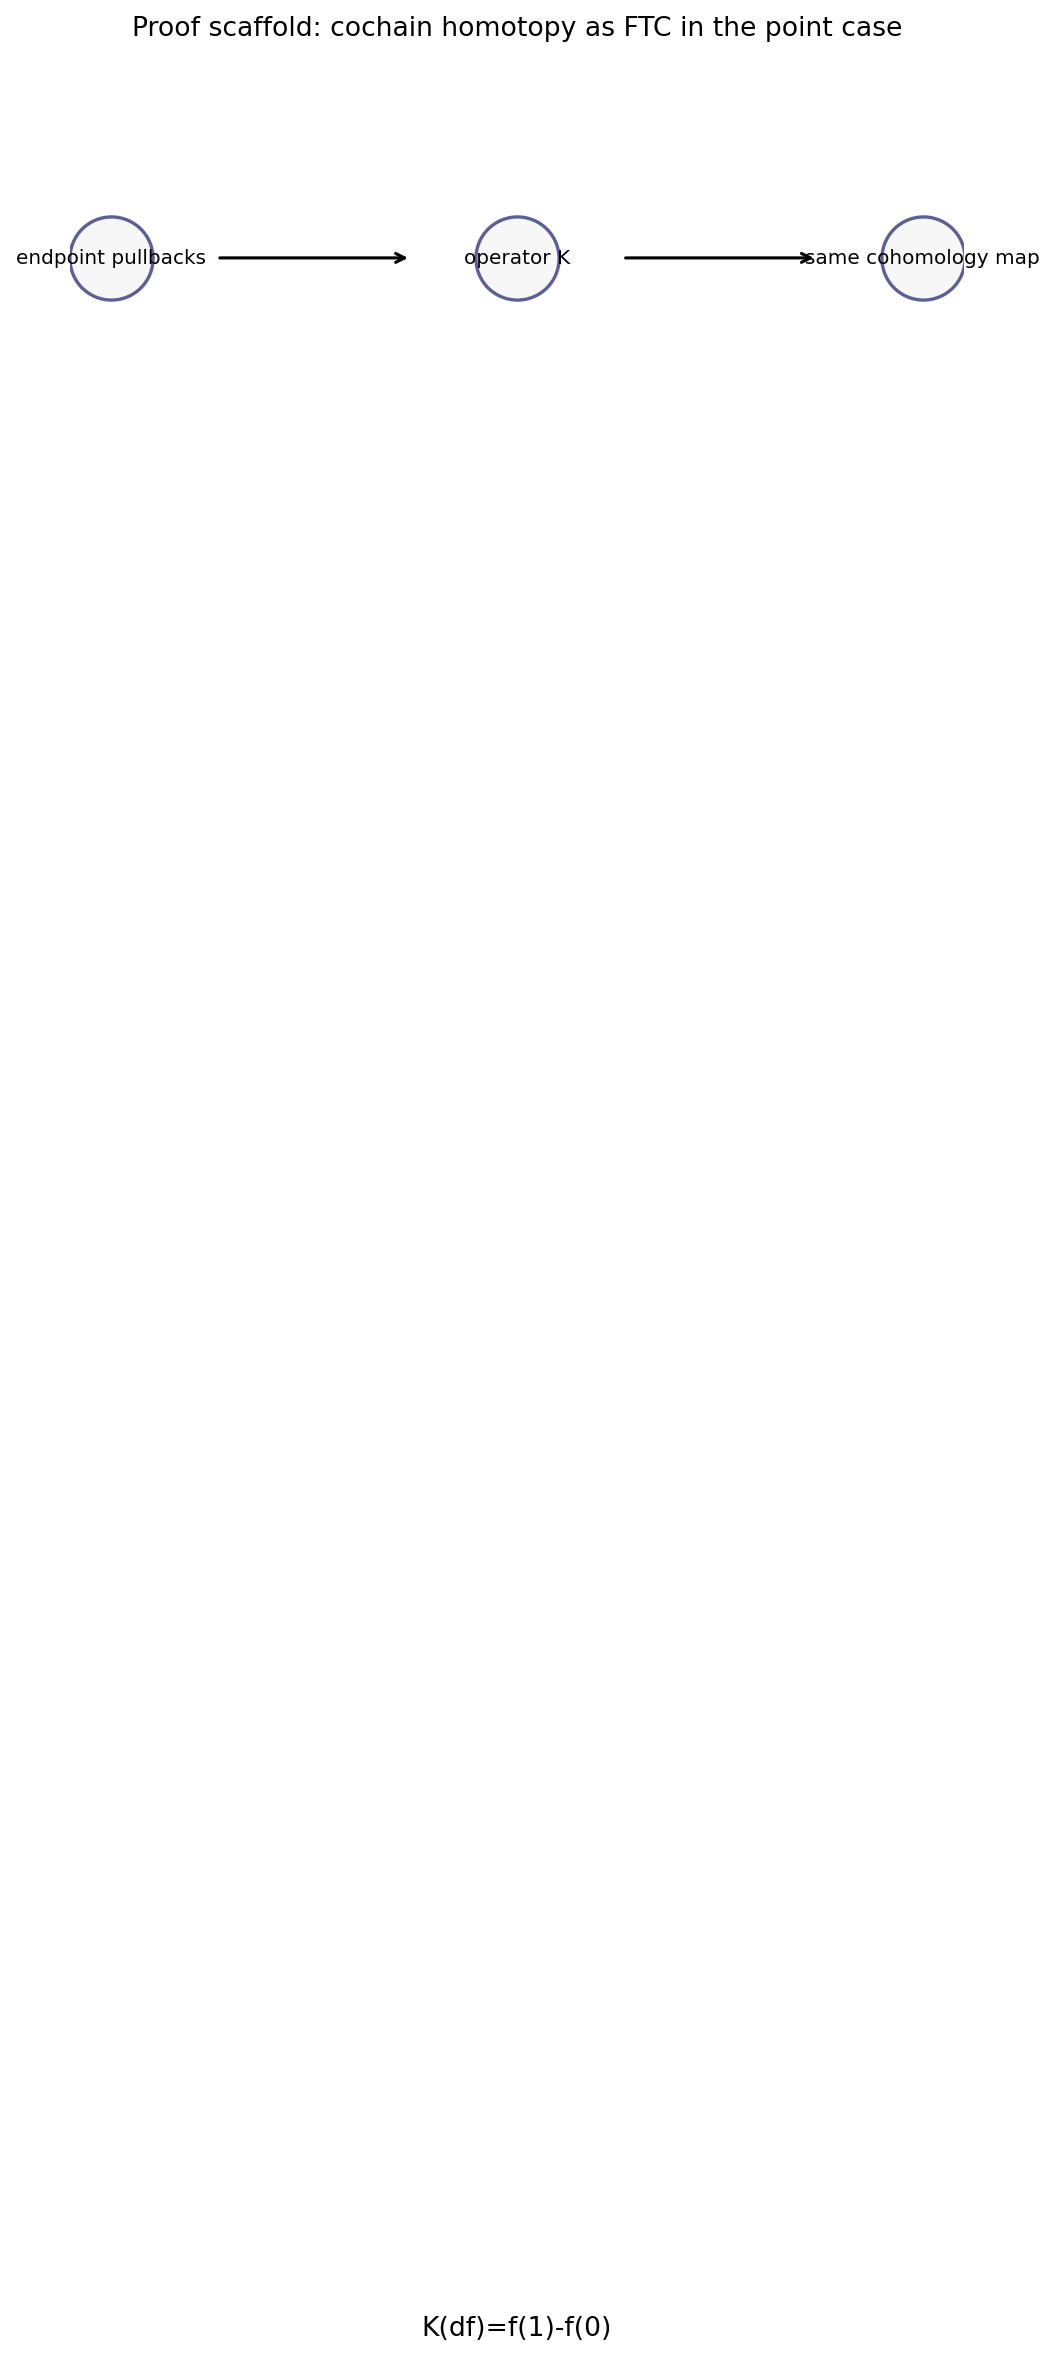

{'function': 'tau**4 - 2*tau**2 + tau + 3',
 'K_df': '0',
 'endpoint_difference': '0',
 'residual': '0',
 'identity_verified': True}

In [7]:
tau = sp.symbols("tau", real=True)
f_tau = tau**4 - 2*tau**2 + tau + 3
K_df = sp.integrate(sp.diff(f_tau, tau), (tau, 0, 1))
endpoint_difference = sp.simplify(f_tau.subs(tau, 1) - f_tau.subs(tau, 0))
cochain_homotopy_residual = sp.simplify(K_df - endpoint_difference)
proof_rows = [
    {"proof_object": "i_1^* f - i_0^* f", "point_case_value": str(endpoint_difference)},
    {"proof_object": "K(df)", "point_case_value": str(K_df)},
    {"proof_object": "residual", "point_case_value": str(cochain_homotopy_residual)},
]
proof_table_path = keep(save_csv(proof_rows, TABLE / "cochain-homotopy-point-case.csv"))
fig, ax = plt.subplots(figsize=(7.2, 3.4))
xs = [0.15, 0.5, 0.85]
labels = ["endpoint pullbacks", "operator K", "same cohomology map"]
for xpos, label in zip(xs, labels):
    ax.scatter([xpos], [0.55], s=1400, color="#f7f7f7", edgecolor="#5b5f97", linewidth=1.5)
    ax.text(xpos, 0.55, label, ha="center", va="center", fontsize=9)
ax.annotate("", xy=(xs[1]-0.09,0.55), xytext=(xs[0]+0.09,0.55), arrowprops={"arrowstyle":"->", "lw":1.4})
ax.annotate("", xy=(xs[2]-0.09,0.55), xytext=(xs[1]+0.09,0.55), arrowprops={"arrowstyle":"->", "lw":1.4})
ax.text(0.5, 0.25, r"K(df)=f(1)-f(0)", ha="center", fontsize=12)
ax.set_axis_off()
ax.set_title("Proof scaffold: cochain homotopy as FTC in the point case")
proof_path = keep(save_matplotlib(fig, FIG / "cochain-homotopy-proof-scaffold.png"))
plt.close(fig)
proof_check = {
    "function": str(f_tau),
    "K_df": str(K_df),
    "endpoint_difference": str(endpoint_difference),
    "residual": str(cochain_homotopy_residual),
    "identity_verified": bool(cochain_homotopy_residual == 0),
}
proof_check_path = keep(save_json(proof_check, CHECK / "cochain-homotopy-proof-check.json"))
display_artifact(proof_path, width=720)
proof_check

## Takeaways

- De Rham cohomology is the quotient of closed forms by exact forms; it measures global obstructions to finding potentials.
- Periods over cycles are practical witnesses. The angular form is closed locally but has nonzero period, so it represents a nontrivial class.
- Exact sequences, connecting homomorphisms, and Mayer-Vietoris provide calculational infrastructure, not just abstract decoration.
- Homotopy invariance allows deformation retractions to simplify spaces while preserving cohomology. This is why the punctured plane and circle share the same first de Rham class.
- The ring structure records products of classes; on the torus, two degree-one classes wedge to the top class.
- The proof of homotopy invariance is a cochain-homotopy identity. In the smallest interval model it is exactly the fundamental theorem of calculus.

The final sanity check confirms the period obstruction, exactness ledger, Mayer-Vietoris dimension, deformation-retraction consequence, Betti/Euler table, cochain-homotopy identity, and artifact contract.

In [8]:
# final_sanity
final_sanity = {
    "angular_form_closed": angular_check["exterior_derivative_coefficient_away_from_origin"] == "0",
    "angular_period_nonzero": abs(angular_check["unit_circle_period_numeric"]) > 6.0,
    "exact_sequence_middle_exact": sequence_check["middle_exact"],
    "mayer_vietoris_circle_h1_one": mv_check["computed_dim_H1_S1"] == 1,
    "retraction_preserves_period": retraction_check["preserves_angular_period"],
    "genus_3_euler_minus_4": betti_check["genus_3_euler"] == -4,
    "cochain_homotopy_identity": proof_check["identity_verified"],
    "artifact_count": len(created_artifacts),
}
final_sanity_path = keep(save_json(final_sanity, CHECK / "final-sanity.json"))
assert final_sanity["angular_form_closed"]
assert final_sanity["angular_period_nonzero"]
assert final_sanity["exact_sequence_middle_exact"]
assert final_sanity["mayer_vietoris_circle_h1_one"]
assert final_sanity["retraction_preserves_period"]
assert final_sanity["genus_3_euler_minus_4"]
assert final_sanity["cochain_homotopy_identity"]
assert_artifacts(created_artifacts, min_bytes=40)
final_sanity

{'angular_form_closed': True,
 'angular_period_nonzero': True,
 'exact_sequence_middle_exact': True,
 'mayer_vietoris_circle_h1_one': True,
 'retraction_preserves_period': True,
 'genus_3_euler_minus_4': True,
 'cochain_homotopy_identity': True,
 'artifact_count': 16}